# Collect_results
1. Models:
    1. baseline
    2. gaussian blur
    3. haar wavelet
    4. frozen unet: using retangular mask, preserved raio from 0.1-0.5
        - use pretrain and frozen during hidden pipeline training
2. eval attacks:
    1. mean
    2. telea
    3. navier
    4. shiftmap
    5. PDE based diffusion
3. masks:
    1. retangular mask for sweep, preserved ratio from  0.1 to 0.9
    2. sparse mask, preserved ratio: 0.1, 0.3
        - optimized mask, using ps and nlpe, 2 parameter set:
            - a. diffusion=150, nlpe=100 
            - b. diffusion=300, nlpe=200 
        - random mask, use seed=42 to generated.
4. results table:
    1. retangular mask: 4 models, 5 attacks, using sweep
    2. sparse mask: 4 models, 4 attacks(without shiftmap since it's pixel-wised mask)
5. key measure indicators:
    - attacked images:
        1. BER, decoded message error rate, lower means weaker attack
        2. SSIM and PSNR, image quality, higher means better quality
    - models:
        1. use run validated results's data



In [1]:
output_folder_path = "/home/keen/HiDDeN/output"
#path validate trained model's output
trained_baseline_info_path = "/home/keen/HiDDeN/evaluation_3k_baseline_results.json"
trained_frozen_unet_info_path = "/home/keen/HiDDeN/evaluation_3k_frozen_pretrained_unet_eval_aligned_results.json"
trained_gaussian_blur_info_path = "/home/keen/HiDDeN/evaluation_3k_gaussian_blur_results.json"
trained_haar_wavelet_info_path = "/home/keen/HiDDeN/evaluation_3k_haar_wavelet_results.json"

#path, retangular mask, sweep results
# removal ratio = 0, original
clean_sweep_baseline_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_baseline_S_42.json"
clean_sweep_frozen_unet_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_frozen_pretrained_unet_eval_aligned_S_42.json"
clean_sweep_gaussian_blur_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_gaussian_blur_S_42.json"
clean_sweep_haar_wavelet_path = "/home/keen/HiDDeN/sweep_results/clean_M_3k_haar_wavelet_S_42.json"
#sweep result:
sweep_baseline_A_mean_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_mean_R_0.10_0.90_S_42.json"
sweep_baseline_A_diffusion_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_diffusion_R_0.10_0.90_S_42.json"
sweep_baseline_A_telea_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_telea_R_0.10_0.90_S_42.json"
sweep_baseline_A_shiftmap_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_shiftmap_R_0.10_0.90_S_42.json"
sweep_baseline_A_navier_path = "/home/keen/HiDDeN/sweep_results/sweep_M_3k_baseline_A_navier_R_0.10_0.90_S_42.json"
# optimized mask result:4 set parameters, 4 models, 5 attacks, diffusion, mean, telea, shiftmap, navier
# here is just illustration, other model and attack have similiar format
# diff 150, nlpe 100, density 10%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.1__val_ps_nlpe_masks_density_100__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.1__val_ps_nlpe_masks_density_100__seed_42/images"
# diff 150, nlpe 100, density 30%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.3__val_ps_nlpe_masks_density_300__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_150_nlpe_100_den_0.3__val_ps_nlpe_masks_density_300__seed_42/images"
# diff 300, nlpe 200, density 10%
opt_mask_baseline_A_diffusion_diff_300_nlpe_200_den_100_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.1__val_ps_nlpe_masks_density_100__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.1__val_ps_nlpe_masks_density_100__seed_42/images"
# diff 300, nlpe 200, density 30%
opt_mask_baseline_A_diffusion_diff_300_nlpe_200_den_100_result_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.3__val_ps_nlpe_masks_density_300__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_300_nlpe_200_den_100_first_10_images_path = "/home/keen/HiDDeN/optimized_mask_eval_outputs/M_3k_baseline__A_diffusion__opt_masks_diff_300_nlpe_200_den_0.3__val_ps_nlpe_masks_density_300__seed_42/images"

# sparse random mask result:2 set parameters, 4 models, 4 attacks, diffusion, mean, telea, navier
# here is just illustration, other model and attack have similiar format
# density 10%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_result_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.1_seed_42__val_random_masks_density_100__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_100_first_10_images_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.1_seed_42__val_random_masks_density_100__seed_42/images"
# density 30%
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_result_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.3_seed_42__val_random_masks_density_300__seed_42/evaluation_results.json"
opt_mask_baseline_A_diffusion_diff_150_nlpe_100_den_300_first_10_images_path = "/home/keen/HiDDeN/sparse_random_mask_eval_outputs/M_3k_baseline__A_diffusion__random_masks_den_0.3_seed_42__val_random_masks_density_300__seed_42/images"

In [2]:
# model names:
baseline_run = "3k_baseline 2026.05.13--12-17-40"
unet_run = "3k_frozen_pretrained_unet_eval_aligned 2026.08.24--04-07-29"
gaussian_blur_run = "3k_gaussian_blur 2026.05.26--18-42-22"
haar_wavelet_run = "3k_haar_wavelet 2026.05.26--12-12-55"

In [3]:
# commands: 
# get models info
"""
python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_baseline 2026.05.13--12-17-40"

python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_frozen_pretrained_unet_eval_aligned 2026.08.24--04-07-29"

python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_gaussian_blur 2026.05.26--18-42-22"

python validate-trained-models.py \
    -d images \
    -r runs \
    --run-name "3k_haar_wavelet 2026.05.26--12-12-55"
"""

'\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_baseline 2026.05.13--12-17-40"\n\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_frozen_pretrained_unet_eval_aligned 2026.08.24--04-07-29"\n\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_gaussian_blur 2026.05.26--18-42-22"\n\npython validate-trained-models.py     -d images     -r runs     --run-name "3k_haar_wavelet 2026.05.26--12-12-55"\n'

In [4]:
# scripts for sweep summary tables:
# python collect_results.py

# scripts for opt_mask and sparse_random_mask
# python collect_sparse_results.py

# plots
### sweep results visualization

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


csv_path = Path("/home/keen/HiDDeN/output/csv/rectangular_mask_results.csv")

df = pd.read_csv(csv_path)

df.head()

,model,attack,removal_ratio,PSNR,SSIM,BER
0,Baseline,mean,0.1,24.082294,0.866239,0.028556
1,Baseline,mean,0.2,21.282916,0.792153,0.030111
2,Baseline,mean,0.3,19.511084,0.720505,0.034889
3,Baseline,mean,0.4,18.208468,0.651576,0.042889
4,Baseline,mean,0.5,17.158511,0.585099,0.060000


In [6]:
print(df.columns)

print("\nModels:")
print(df["model"].unique())

print("\nAttacks:")
print(df["attack"].unique())

Index(['model', 'attack', 'removal_ratio', 'PSNR', 'SSIM', 'BER'], dtype='object')

Models:
['Baseline' 'Gaussian Blur' 'Haar Wavelet' 'Frozen UNet']

Attacks:
['mean' 'telea' 'navier' 'shiftmap' 'diffusion']


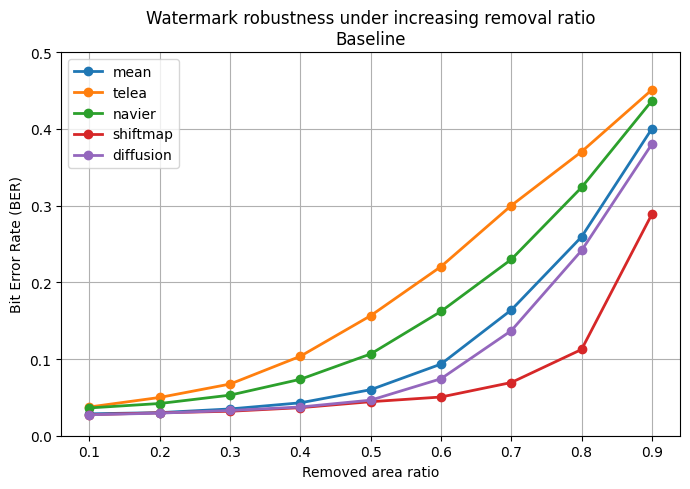

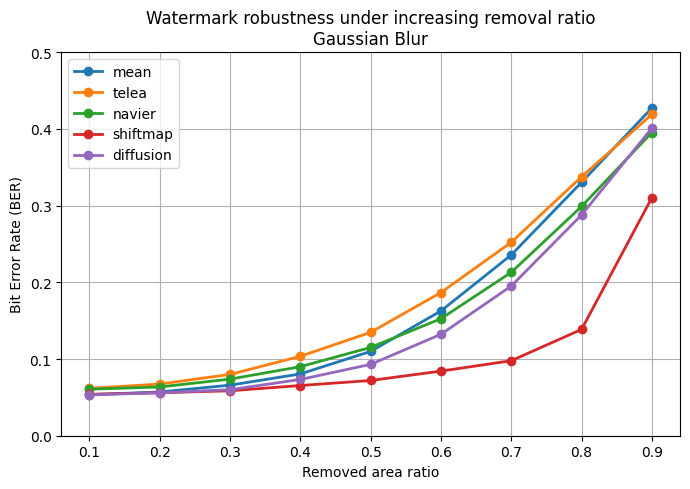

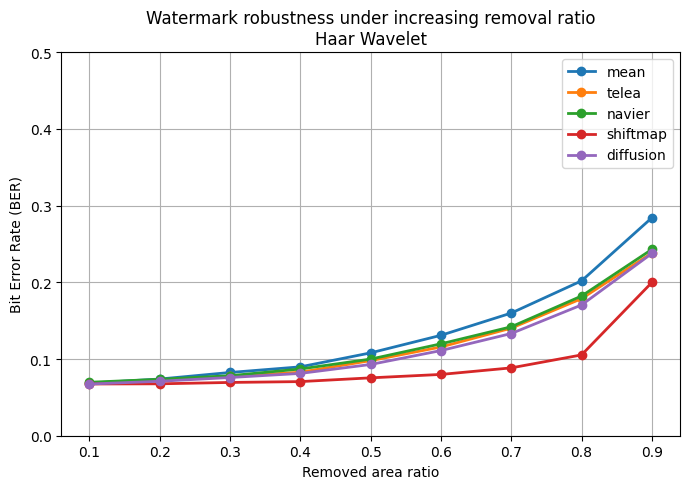

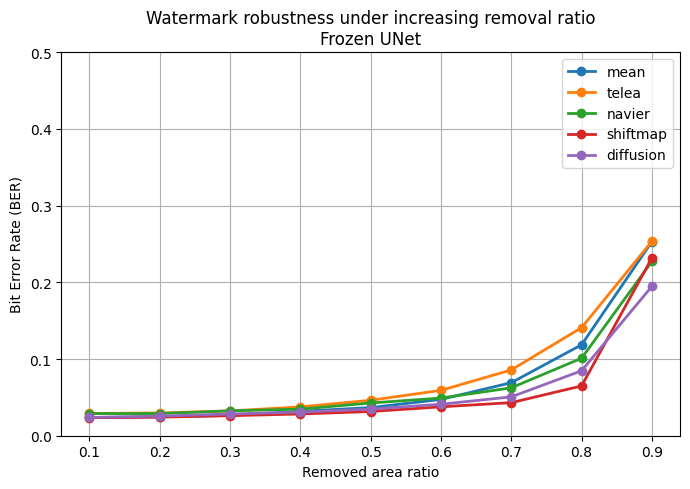

In [7]:
models = df["model"].unique()

fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(exist_ok=True)


for model in models:
    
    plt.figure(figsize=(7,5))
    
    model_df = df[df["model"] == model]
    
    for attack in model_df["attack"].unique():
        
        attack_df = (
            model_df[model_df["attack"] == attack]
            .sort_values("removal_ratio")
        )
        
        plt.plot(
            attack_df["removal_ratio"],
            attack_df["BER"],
            marker="o",
            linewidth=2,
            label=attack
        )
    
    plt.xlabel("Removed area ratio")
    plt.ylabel("Bit Error Rate (BER)")
    
    plt.title(
        f"Watermark robustness under increasing removal ratio\n{model}"
    )
    
    plt.ylim(0, 0.5)
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    
    filename = (
        model.lower()
        .replace(" ", "_")
        .replace("/", "_")
        + "_ber_sweep.png"
    )
    
    plt.savefig(
        fig_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [ ]:
# model info
val_df = pd.read_csv(
    "/home/keen/HiDDeN/output/csv/validation_results.csv"
)

val_df.head()

,model,PSNR,SSIM,BER
0,Baseline,34.2996,0.9436,0.027333
1,Gaussian Blur,33.0676,0.9212,0.076333
2,Haar Wavelet,29.7277,0.8960,0.089556
3,Frozen UNet,33.3698,0.9286,0.025333


In [9]:
#sparse mask
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# random sparse masks
random_mask_path_01 = Path("/home/keen/HiDDeN/sparse_random_masks_data/random_masks_den_0.1_seed_42/val_random_masks_density_100.npy")
random_mask_path_03 = Path("/home/keen/HiDDeN/sparse_random_masks_data/random_masks_den_0.3_seed_42/val_random_masks_density_300.npy")

# optimized sparse masks (final version used in thesis: PS + NLPE)
optimized_mask_path_01 = Path(
    "/home/keen/HiDDeN/opt_masks_data/opt_masks_diff_150_nlpe_100_den_0.1/val_ps_nlpe_masks_density_100.npy"
)

optimized_mask_path_03 = Path(
    "/home/keen/HiDDeN/opt_masks_data/opt_masks_diff_150_nlpe_100_den_0.3/val_ps_nlpe_masks_density_300.npy"
)

In [10]:
random_masks_01 = np.load(random_mask_path_01)
optimized_masks_01 = np.load(optimized_mask_path_01)

random_masks_03 = np.load(random_mask_path_03)
optimized_masks_03 = np.load(optimized_mask_path_03)

print("random 0.1:", random_masks_01.shape)
print("optimized 0.1:", optimized_masks_01.shape)
print("random 0.3:", random_masks_03.shape)
print("optimized 0.3:", optimized_masks_03.shape)

random 0.1: (300, 128, 128)
optimized 0.1: (300, 128, 128)
random 0.3: (300, 128, 128)
optimized 0.3: (300, 128, 128)


In [11]:
mean_random_01 = random_masks_01.mean(axis=0)
mean_optimized_01 = optimized_masks_01.mean(axis=0)

mean_random_03 = random_masks_03.mean(axis=0)
mean_optimized_03 = optimized_masks_03.mean(axis=0)

/tmp/ipykernel_453276/2043787363.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


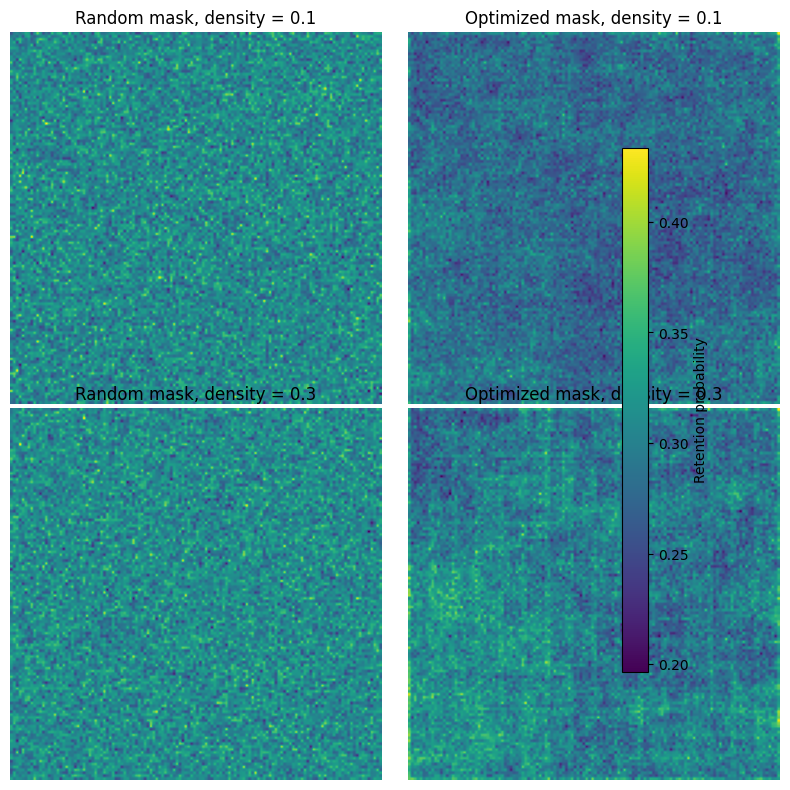

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

im1 = axes[0, 0].imshow(mean_random_01)
axes[0, 0].set_title("Random mask, density = 0.1")
axes[0, 0].axis("off")

im2 = axes[0, 1].imshow(mean_optimized_01)
axes[0, 1].set_title("Optimized mask, density = 0.1")
axes[0, 1].axis("off")

im3 = axes[1, 0].imshow(mean_random_03)
axes[1, 0].set_title("Random mask, density = 0.3")
axes[1, 0].axis("off")

im4 = axes[1, 1].imshow(mean_optimized_03)
axes[1, 1].set_title("Optimized mask, density = 0.3")
axes[1, 1].axis("off")

cbar = fig.colorbar(im4, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Retention probability")

plt.tight_layout()
plt.show()

/tmp/ipykernel_453276/331939236.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


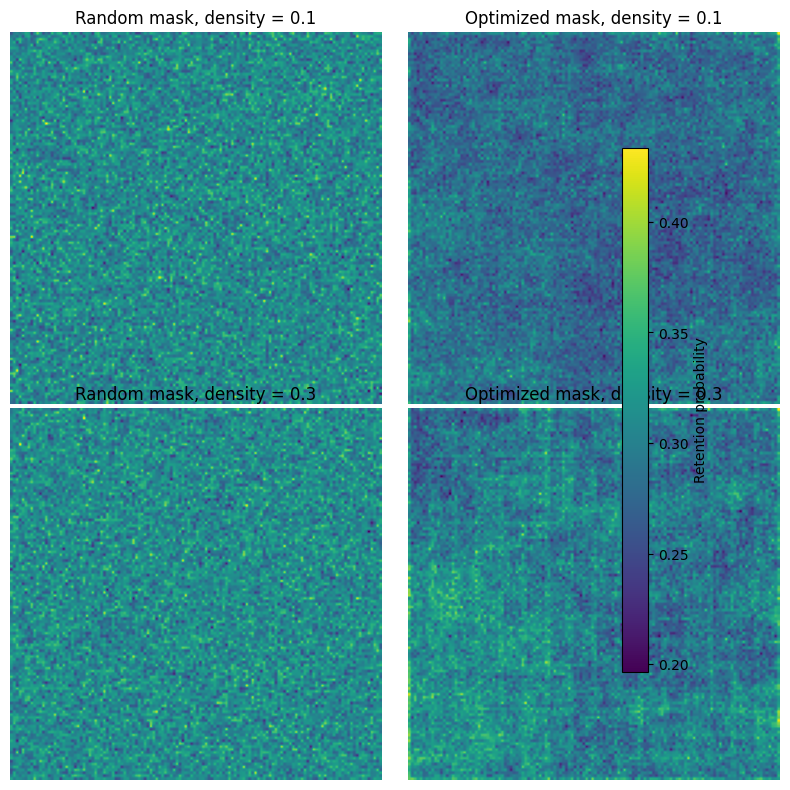

In [13]:
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

im1 = axes[0, 0].imshow(mean_random_01)
axes[0, 0].set_title("Random mask, density = 0.1")
axes[0, 0].axis("off")

im2 = axes[0, 1].imshow(mean_optimized_01)
axes[0, 1].set_title("Optimized mask, density = 0.1")
axes[0, 1].axis("off")

im3 = axes[1, 0].imshow(mean_random_03)
axes[1, 0].set_title("Random mask, density = 0.3")
axes[1, 0].axis("off")

im4 = axes[1, 1].imshow(mean_optimized_03)
axes[1, 1].set_title("Optimized mask, density = 0.3")
axes[1, 1].axis("off")

cbar = fig.colorbar(im4, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Retention probability")

plt.tight_layout()
plt.savefig(fig_dir / "mean_mask_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# PSNR–BER trade-off scatter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/home/keen/HiDDeN/output/csv/sparse_mask_results.csv")
sparse_df = pd.read_csv(csv_path)

sparse_df.head()

,model,mask_type,density,attack,PSNR,SSIM,BER,num_images
0,Frozen UNet,Optimized_d300_n200,0.3,navier,30.339326,0.873680,0.272889,300
1,Baseline,Optimized_d300_n200,0.1,telea,23.411635,0.682666,0.478222,300
2,Haar Wavelet,Optimized_d150_n100,0.1,mean,14.284555,0.437911,0.444667,300
3,Gaussian Blur,Optimized_d150_n100,0.3,mean,15.650209,0.478348,0.384667,300
4,Gaussian Blur,Optimized_d150_n100,0.1,mean,14.324939,0.435390,0.461889,300


In [15]:
print("Models:", sparse_df["model"].unique())
print("Mask types:", sparse_df["mask_type"].unique())
print("Attacks:", sparse_df["attack"].unique())
print("Densities:", sparse_df["density"].unique())

Models: ['Frozen UNet' 'Baseline' 'Haar Wavelet' 'Gaussian Blur']
Mask types: ['Optimized_d300_n200' 'Optimized_d150_n100' 'Random']
Attacks: ['navier' 'telea' 'mean' 'diffusion']
Densities: [0.3 0.1]


In [16]:
attacks_to_use = ["mean", "telea", "navier", "diffusion"]

plot_df = (
    sparse_df[
        (sparse_df["model"] == "Baseline") &
        (sparse_df["attack"].isin(attacks_to_use))
    ]
    .groupby(["mask_type", "density"])[["PSNR", "BER"]]
    .mean()
    .reset_index()
)

plot_df

,mask_type,density,PSNR,BER
0,Optimized_d150_n100,0.1,22.197247,0.484722
1,Optimized_d150_n100,0.3,26.819511,0.357861
2,Optimized_d300_n200,0.1,22.371062,0.483389
3,Optimized_d300_n200,0.3,26.827172,0.352861
4,Random,0.1,20.028371,0.486111
5,Random,0.3,22.349628,0.392028


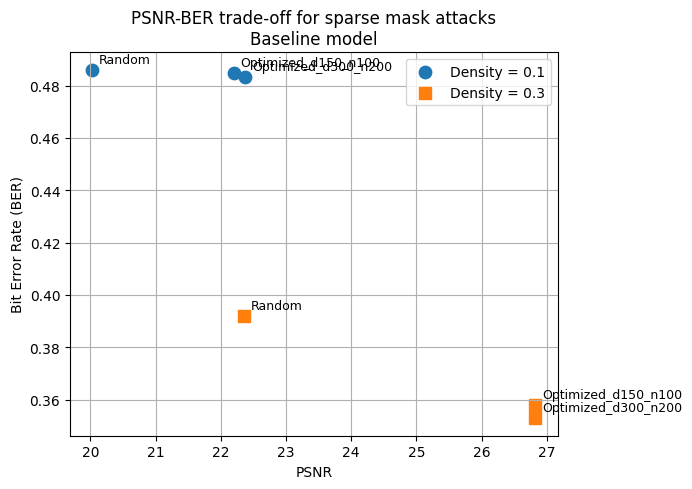

In [18]:
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 5))

for density in sorted(plot_df["density"].unique()):
    density_df = plot_df[plot_df["density"] == density]
    
    plt.scatter(
        density_df["PSNR"],
        density_df["BER"],
        s=80,
        marker="o" if density == 0.1 else "s",
        label=f"Density = {density}"
    )
    
    for _, row in density_df.iterrows():
        plt.annotate(
            row["mask_type"],
            (row["PSNR"], row["BER"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

plt.xlabel("PSNR")
plt.ylabel("Bit Error Rate (BER)")
plt.title("PSNR-BER trade-off for sparse mask attacks\nBaseline model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "psnr_ber_tradeoff_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

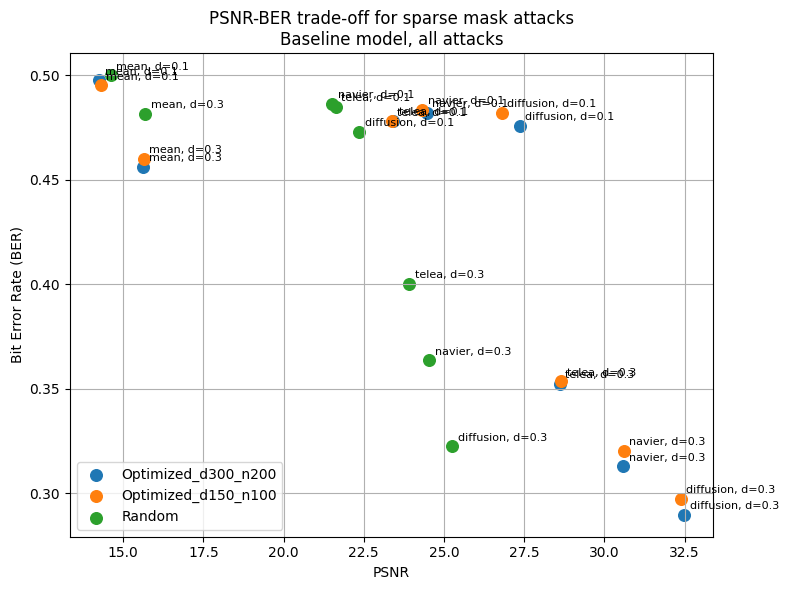

In [20]:
# all the different attacks
fig_dir = Path("/home/keen/HiDDeN/output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df_full = sparse_df[
    (sparse_df["model"] == "Baseline") &
    (sparse_df["attack"].isin(attacks_to_use))
].copy()

plt.figure(figsize=(8, 6))

for mask_type in plot_df_full["mask_type"].unique():
    subset = plot_df_full[plot_df_full["mask_type"] == mask_type]
    plt.scatter(
        subset["PSNR"],
        subset["BER"],
        s=70,
        label=mask_type
    )
    
    for _, row in subset.iterrows():
        label = f'{row["attack"]}, d={row["density"]}'
        plt.annotate(
            label,
            (row["PSNR"], row["BER"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("PSNR")
plt.ylabel("Bit Error Rate (BER)")
plt.title("PSNR-BER trade-off for sparse mask attacks\nBaseline model, all attacks")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "psnr_ber_tradeoff_baseline_full_attacks.png", dpi=300, bbox_inches="tight")
plt.show()
   